In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pylab import *
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
from cartopy.feature import ShapelyFeature
import cartopy.feature as cfeature

In [2]:
path = '/nfs/scistore16/mullegrp/acasalla/Reanalysis/Reversals/'

ds_u = xr.open_dataset(f'{path}Zonalu_area.nc')
ds_v = xr.open_dataset(f'{path}Meridionalv_area.nc')

# Wind profiles

In [3]:
def seas_shear(ds_u, ds_v):
    # Calculate wind speed
    wind_speed = np.sqrt(ds_u['u']**2 + ds_v['v']**2)
    
    # Calculate the seasonal mean of u and v components
    seasonal_mean_u = ds_u['u'].groupby('time.season').mean('time')
    seasonal_mean_v = ds_v['v'].groupby('time.season').mean('time')
    
    # Calculate wind speed from the seasonal mean u and v components
    seasonal_mean_speed = wind_speed.groupby('time.season').mean('time')
    
    # Calculate wind direction from the seasonal mean u and v components
    seasonal_mean_direction_radians = np.arctan2(seasonal_mean_v, seasonal_mean_u)
    seasonal_mean_direction_degrees = np.degrees(seasonal_mean_direction_radians)
    
    # Convert direction to the range [0, 360)
    seasonal_mean_direction = (seasonal_mean_direction_degrees + 180) % 360
    
    return(seasonal_mean_speed, seasonal_mean_u, seasonal_mean_v)

In [4]:
seas_mag, seas_u, seas_v = seas_shear(ds_u, ds_v)

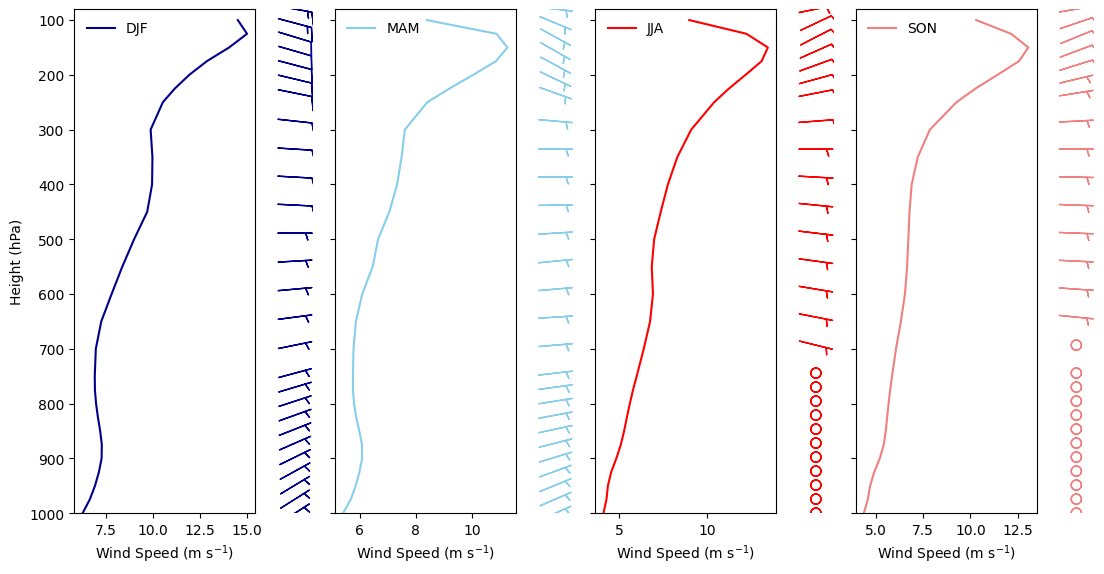

In [5]:
fig = plt.figure(figsize=(12,6))
gs = gridspec.GridSpec(1,8,left = 0.1, right = 0.95, hspace=0.2, wspace=0.2, top = 0.92, bottom = 0.08, width_ratios = [1,0.2,1,0.2,1,0.2,1,0.2])
sea_num = [0,2,1,3]
sea_name = ['DJF','MAM','JJA','SON']
colors = ['darkblue','skyblue','red','lightcoral']
pos1 = [0,2,4,6]
pos2 = [1,3,5,7]

for i,seas in enumerate(sea_name):
    ax = plt.subplot(gs[pos1[i]])
    plt.plot(seas_mag.mean(dim=['latitude', 'longitude'])[sea_num[i],:], seas_mag.level, color = colors[i], label = sea_name[i])
    plt.ylim(1000,80)
    if i == 0:
        plt.ylabel('Height (hPa)')
    else:
        ax.yaxis.set_major_formatter(NullFormatter())
    plt.xlabel('Wind Speed (m s$^{-1}$)')
    plt.legend(frameon = False)
    plt.yticks(np.arange(1000,99,-100))

for i,seas in enumerate(sea_name):
    ax = plt.subplot(gs[pos2[i]])
    ax.barbs(np.zeros_like(seas_mag.level), seas_mag.level, seas_u.mean(dim=['latitude', 'longitude'])[sea_num[i],:], seas_v.mean(dim=['latitude', 'longitude'])[sea_num[i],:], length=7, pivot='middle', color = colors[i])
    plt.ylim(1000,100)
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    plt.xticks([])
    plt.yticks([])

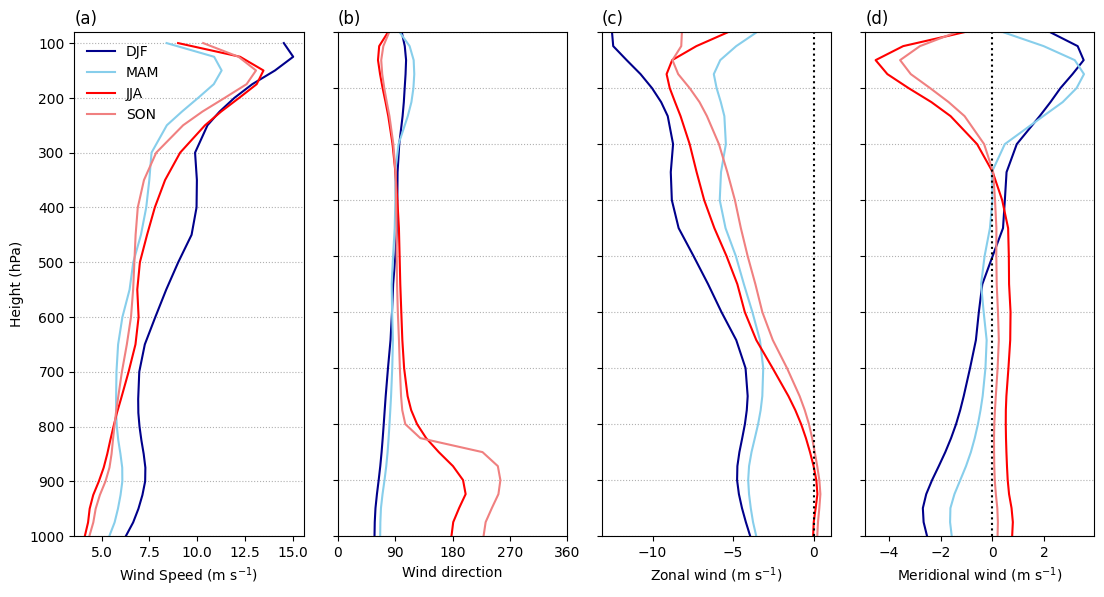

In [33]:
fig = plt.figure(figsize=(12,6))
gs = gridspec.GridSpec(1,4,left = 0.1, right = 0.95, hspace=0.2, wspace=0.15, top = 0.92, bottom = 0.08)
sea_num = [0,2,1,3]
sea_name = ['DJF','MAM','JJA','SON']
colors = ['darkblue','skyblue','red','lightcoral']
pos1 = [0,2,4,6]
pos2 = [1,3,5,7]

ax = plt.subplot(gs[0])
for i,seas in enumerate(sea_name):
    plt.plot(seas_mag.mean(dim=['latitude', 'longitude'])[sea_num[i],:], seas_mag.level, color = colors[i], label = sea_name[i])
plt.ylim(1000,80)
plt.grid(axis = 'y', linestyle = ':')
plt.ylabel('Height (hPa)')  
plt.xlabel('Wind Speed (m s$^{-1}$)')
plt.legend(frameon = False)
plt.yticks(np.arange(1000,99,-100))
plt.title('(a)', loc = 'left')

ax = plt.subplot(gs[1])
for i,seas in enumerate(sea_name):
    # Calculate wind direction from the seasonal mean u and v components
    seasonal_mean_direction_radians = np.arctan2(
        seas_u.mean(dim=['latitude', 'longitude'])[sea_num[i],:], 
        seas_v.mean(dim=['latitude', 'longitude'])[sea_num[i],:]
    )
    seasonal_mean_direction_degrees = np.degrees(seasonal_mean_direction_radians)
    
    # Unwrap the angles to avoid discontinuities
    smooth_direction = np.unwrap(np.radians(seasonal_mean_direction_degrees), discont=np.radians(180))
    smooth_direction = np.degrees(smooth_direction) % 360
    test = (seasonal_mean_direction_degrees+180) % 360
    
    plt.plot(test, seas_mag.level, color = colors[i], linestyle = '-')
    #plt.plot(smooth_direction, seas_mag.level, color = colors[i])
    
plt.ylim(1000,100)
plt.grid(axis = 'y', linestyle = ':')
ax.yaxis.set_major_formatter(NullFormatter())
plt.xlabel('Wind direction')
plt.title('(b)', loc = 'left')
xticks = np.arange(0, 361, 90)
xtick_labels = ['South', 'West', 'North', 'East', 'South']
plt.xticks(xticks)#, xtick_labels)

ax = plt.subplot(gs[2])
for i,seas in enumerate(sea_name):
    plt.plot(seas_u.mean(dim=['latitude', 'longitude'])[sea_num[i],:], seas_mag.level, color = colors[i], label = sea_name[i])
    
plt.axvline(0, linestyle = ':', color = 'k')
plt.ylim(1000,100)
plt.grid(axis = 'y', linestyle = ':')
ax.yaxis.set_major_formatter(NullFormatter())
plt.xlabel('Zonal wind (m s$^{-1}$)')
plt.title('(c)', loc = 'left')

ax = plt.subplot(gs[3])
for i,seas in enumerate(sea_name):
    plt.plot(seas_v.mean(dim=['latitude', 'longitude'])[sea_num[i],:], seas_mag.level, color = colors[i], label = sea_name[i])

plt.axvline(0, linestyle = ':', color = 'k')
plt.ylim(1000,100)
plt.grid(axis = 'y', linestyle = ':')
ax.yaxis.set_major_formatter(NullFormatter())
plt.xlabel('Meridional wind (m s$^{-1}$)')
plt.title('(d)', loc = 'left')
plt.savefig('Plots/Wind_profiles_reversals.jpg', bbox_inches = 'tight', dpi = 300)
plt.savefig('Plots/Wind_profiles_reversals.pdf', bbox_inches = 'tight', dpi = 300)

plt.show()

# Tropospheric Shear

### Reversals and organized!

In [7]:
def calculate_shear(ds_u, ds_v, level1, level2, use_mean):
    """
    Calculate wind shear between two pressure levels or between the means of two pressure level ranges.
    
    Parameters:
    ds_u (xarray.Dataset): Dataset containing the zonal wind component (u).
    ds_v (xarray.Dataset): Dataset containing the meridional wind component (v).
    level1 (int or tuple): Single pressure level or first pressure level range (e.g., 500 or (500, 700) hPa). Always the smaller one, so further of the surface.
    level2 (int or tuple): Single pressure level or second pressure level range (e.g., 850 or (800, 1000) hPa). Always the large one, so closer to the surface.
    use_mean (bool): Whether to use the mean of the specified ranges instead of individual levels.
    
    Returns:
    shear_magnitude (xarray.DataArray): The wind shear magnitude.
    shear_direction (xarray.DataArray): The wind shear direction (optional).
    """
    
    if use_mean:
        # Select and average the u and v components over the first level range
        u1 = ds_u.sel(level=slice(level1[0], level1[1]))['u'].mean(dim='level')
        v1 = ds_v.sel(level=slice(level1[0], level1[1]))['v'].mean(dim='level')
        
        # Select and average the u and v components over the second level range
        u2 = ds_u.sel(level=slice(level2[0], level2[1]))['u'].mean(dim='level')
        v2 = ds_v.sel(level=slice(level2[0], level2[1]))['v'].mean(dim='level')
        
    else:
        # Select the u and v components at the specific levels
        u1 = ds_u.sel(level=level1)['u']
        v1 = ds_v.sel(level=level1)['v']
        
        u2 = ds_u.sel(level=level2)['u']
        v2 = ds_v.sel(level=level2)['v']
    
    # Calculate the difference between the two layers
    delta_u = u2 - u1
    delta_v = v2 - v1
    
    # Calculate the magnitude of the shear
    #shear_magnitude = np.sqrt(delta_u**2 + delta_v**2)
    
    # Calculate the direction of the shear
    #shear_direction = np.degrees(np.arctan2(delta_v, delta_u))
    
    return delta_u, delta_v

In [8]:
def sum_them(ds, var, dates):
    """
    Select data for the given dates, calculate the weighted mean, and subtract the seasonal mean.
    
    Parameters:
    ds (xarray.Dataset): Dataset containing the variables.
    var (str): Variable name.
    dates (list): List of dates to select.
    
    Returns:
    xarray.DataArray: Resulting weighted mean minus the seasonal mean.
    """
    
    date_filtered = np.unique([date[:10] for date in dates])
    data_list = []
    
    for date in date_filtered:
        try:
            data_list.append(ds[var].sel(time=date))
        except KeyError:
            print(f'Date {date} not available')

    try:
        weights = np.cos(np.deg2rad(ds['latitude']))
    except KeyError:
        weights = np.cos(np.deg2rad(ds['lat']))

    data_concat = xr.concat(data_list, dim='time')
    data_weighted = data_concat.weighted(weights)
    #season_means = ds.groupby('time.season').mean()

    result = data_weighted.mean(dim='time') # - season_means[var].sel(season='JJA')  # Example season 'JJA'

    return result
    
def sel_season(data):
    """
    Select data for the specified months.

    Parameters:
    data (pandas.DataFrame): DataFrame with a datetime index.

    Returns:
    numpy.ndarray: Array of strings representing the selected dates.
    """
    
    tmp = data[data.index.month.isin([12, 1, 2, 3, 4, 5])]
    new_df = tmp.index.strftime('%Y-%m-%d %H:%M:%S').values
    return new_df

def dates_cal(state, latitude, longitude, season):
    filename = 'Dates_'+latitude+'_'+longitude+'_'+state+'.csv'
    dates_rev = pd.read_csv(path+filename, parse_dates = True, index_col = 0)    
    if season == 'MAM':
        tmp_rev = dates_rev[dates_rev.index.month.isin([3,4,5])]
    else:
        tmp_rev = dates_rev[dates_rev.index.month.isin([12,1,2,3,4,5])]
    dat_rev = (tmp_rev.index).strftime('%Y-%m-%d %H:%M:%S').values
    return dat_rev

In [9]:
def calculate_shear_with_selection(delta_u, delta_v, dates):
    """
    Combine shear calculation with date-based selection and seasonal averaging.

    Parameters:
    ds_u, ds_v (xarray.Dataset): Datasets containing the zonal (u) and meridional (v) wind components.
    var (str): Variable name.
    level1, level2 (int or tuple): Levels or level ranges for shear calculation.
    dates (list): List of dates to use for selection.

    Returns:
    shear_magnitude, shear_direction (xarray.DataArray): Calculated shear magnitude and direction.
    """
    
    # Select data for the given dates and apply the weighted mean and seasonal adjustment
    delta_u_sel = sum_them(delta_u.to_dataset(name='u'), 'u', dates)
    delta_v_sel = sum_them(delta_v.to_dataset(name='v'), 'v', dates)

    # Calculate shear magnitude and direction
    shear_magnitude = np.sqrt(delta_u_sel**2 + delta_v_sel**2)
    shear_direction = np.degrees(np.arctan2(delta_v_sel, delta_u_sel))
    shear_direction = (shear_direction + 180) % 360

    return shear_magnitude, shear_direction

In [10]:
levels1 = [200, 500, 700, (500, 700)]
level2 = [850, 1000, 1000, (800, 1000)]
use_mean = [False, False, False, True]

l_trop_she_mag = {}
l_trop_she_dir = {}
states = ['reversals','organised']

for state in states:
    for i,level1 in enumerate(levels1):
        delta_u, delta_v = calculate_shear(ds_u, ds_v, level1, level2[i], use_mean[i])
        dates = dates_cal(state, '2-9', '135-145', 'all')
        if use_mean[i]:
            l_trop_she_mag[f'{level1[0]}_{level1[1]}-{level2[i][0]}_{level2[i][1]}_{state[0:3]}'], l_trop_she_dir[f'{level1[0]}_{level1[1]}-{level2[i][0]}_{level2[i][1]}_{state[0:3]}'] = calculate_shear_with_selection(delta_u, delta_v, dates)
        else:
            l_trop_she_mag[f'{level1}-{level2[i]}_{state[0:3]}'], l_trop_she_dir[f'{level1}-{level2[i]}_{state[0:3]}'] = calculate_shear_with_selection(delta_u, delta_v, dates)

#### Plotting

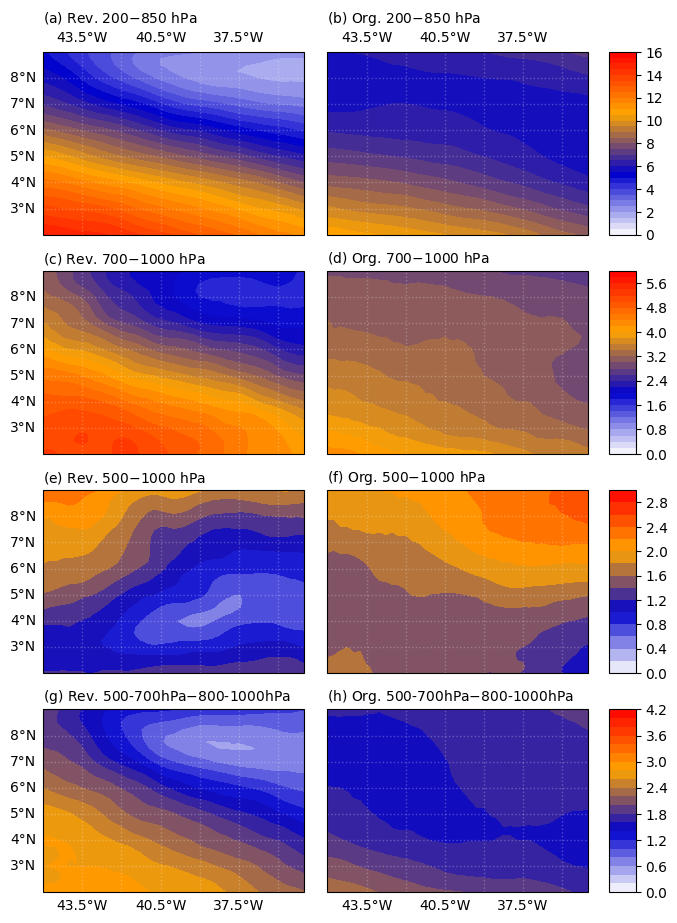

In [11]:
cmap=LinearSegmentedColormap.from_list('', ['white', 'mediumblue','orange','red'])
fig = plt.figure(figsize=(7,10))
gs = gridspec.GridSpec(4,3,left = 0.1, right = 0.95, hspace=0.2, wspace=0.1, top = 0.92, bottom = 0.08, width_ratios = [1,1,0.1])
#levels = [np.arange(0,14.1,0.5), np.arange(0,4.1,0.2), np.arange(0,3.01,0.2), np.arange(0,2.21,0.2)] #MAM
levels = [np.arange(0,16.1,0.5), np.arange(0,6.1,0.2), np.arange(0,3.01,0.2), np.arange(0,4.21,0.2)]

titles = [['(a) Rev. 200$\minus$850 hPa','(c) Rev. 700$\minus$1000 hPa','(e) Rev. 500$\minus$1000 hPa','(g) Rev. 500-700hPa$\minus$800-1000hPa'],
          ['(b) Org. 200$\minus$850 hPa','(d) Org. 700$\minus$1000 hPa','(f) Org. 500$\minus$1000 hPa','(h) Org. 500-700hPa$\minus$800-1000hPa']]

for j,state in enumerate(states):
    for i,level1 in enumerate(levels1):
        ax = plt.subplot(gs[i,j],projection= ccrs.PlateCarree(central_longitude=180))
        if use_mean[i]:
            im = plt.contourf(delta_u.longitude, delta_u.latitude, l_trop_she_mag[f'{level1[0]}_{level1[1]}-{level2[i][0]}_{level2[i][1]}_{state[0:3]}'], levels = levels[i], cmap = cmap)
        else:
            im = plt.contourf(delta_u.longitude, delta_u.latitude, l_trop_she_mag[f'{level1}-{level2[i]}_{state[0:3]}'], levels = levels[i], cmap = cmap)
        plt.title(titles[j][i], loc = 'left', fontsize = 10)
        gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 1, color='w', alpha = 0.25, linestyle = ':')
        if j == 1:
            gl.left_labels = False
            gl.right_labels = False
        elif j == 0:
            gl.right_labels = False
        if i != 0:
            gl.top_labels = False
        if i != 3:
            gl.bottom_labels = False
            
        ### Colorbar
        if j == 1:
            cax = ax = plt.subplot(gs[i,2])
            cbar = plt.colorbar(im, cax = cax, orientation = 'vertical', shrink = 0.9)
        

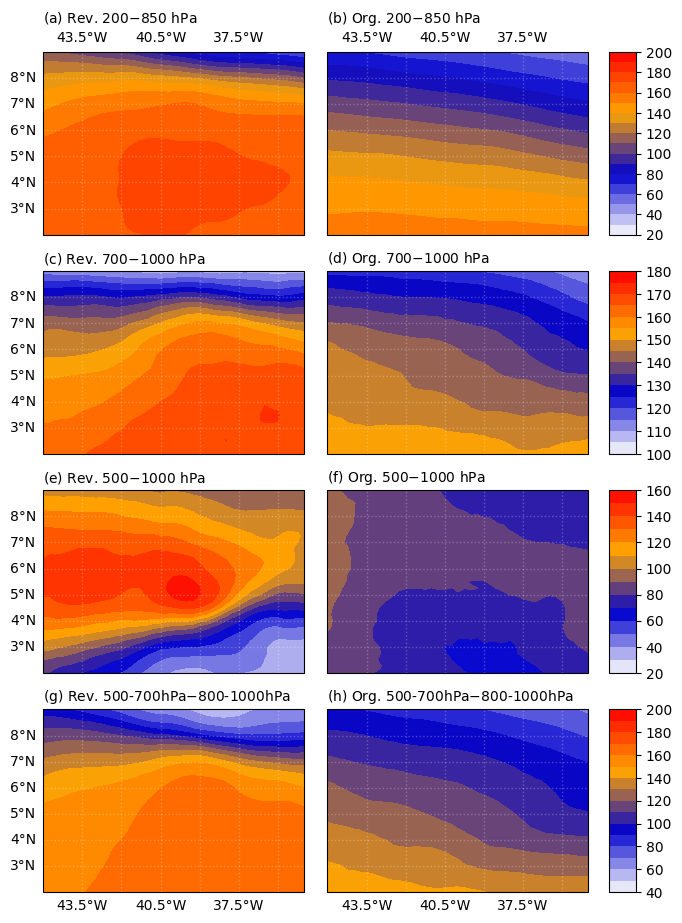

In [12]:
cmap=LinearSegmentedColormap.from_list('', ['white', 'mediumblue','orange','red'])
fig = plt.figure(figsize=(7,10))
gs = gridspec.GridSpec(4,3,left = 0.1, right = 0.95, hspace=0.2, wspace=0.1, top = 0.92, bottom = 0.08, width_ratios = [1,1,0.1])
#levels = [np.arange(20,200.1,10), np.arange(20,170.1,10), np.arange(20,160.1,10), np.arange(0,180.1,10)] #MAM
levels = [np.arange(20,200.1,10), np.arange(100,180.1,5), np.arange(20,160.1,10), np.arange(40,200.1,10)]

titles = [['(a) Rev. 200$\minus$850 hPa','(c) Rev. 700$\minus$1000 hPa','(e) Rev. 500$\minus$1000 hPa','(g) Rev. 500-700hPa$\minus$800-1000hPa'],
          ['(b) Org. 200$\minus$850 hPa','(d) Org. 700$\minus$1000 hPa','(f) Org. 500$\minus$1000 hPa','(h) Org. 500-700hPa$\minus$800-1000hPa']]

for j,state in enumerate(states):
    for i,level1 in enumerate(levels1):
        ax = plt.subplot(gs[i,j],projection= ccrs.PlateCarree(central_longitude=180))
        if use_mean[i]:
            im = plt.contourf(delta_u.longitude, delta_u.latitude, l_trop_she_dir[f'{level1[0]}_{level1[1]}-{level2[i][0]}_{level2[i][1]}_{state[0:3]}'], cmap = cmap, levels = levels[i])
        else:
            im = plt.contourf(delta_u.longitude, delta_u.latitude, l_trop_she_dir[f'{level1}-{level2[i]}_{state[0:3]}'], cmap = cmap, levels = levels[i])
        plt.title(titles[j][i], loc = 'left', fontsize = 10)
        gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 1, color='w', alpha = 0.25, linestyle = ':')
        if j == 1:
            gl.left_labels = False
            gl.right_labels = False
        elif j == 0:
            gl.right_labels = False
        if i != 0:
            gl.top_labels = False
        if i != 3:
            gl.bottom_labels = False
            
        ### Colorbar
        if j == 1:
            cax = ax = plt.subplot(gs[i,2])
            cbar = plt.colorbar(im, cax = cax, orientation = 'vertical', shrink = 0.9)